In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

print("EDA Environment Ready")

EDA Environment Ready


In [2]:
processed_path = Path("../data/processed")
raw_path = Path("../data/raw")

fund_master = pd.read_csv(
    processed_path / "fund_master_clean.csv"
)

nav = pd.read_csv(
    processed_path / "clean_nav.csv"
)

transactions = pd.read_csv(
    processed_path / "clean_transactions.csv"
)

performance = pd.read_csv(
    processed_path / "clean_performance.csv"
)

aum = pd.read_csv(
    raw_path / "03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    raw_path / "04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    raw_path / "05_category_inflows.csv"
)

folio = pd.read_csv(
    raw_path / "06_industry_folio_count.csv"
)

holdings = pd.read_csv(
    raw_path / "09_portfolio_holdings.csv"
)

benchmark = pd.read_csv(
    raw_path / "10_benchmark_indices.csv"
)

print("All datasets loaded")

All datasets loaded


In [6]:
from pathlib import Path

chart_path = Path("../reports/charts")

chart_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Charts folder ready")

Charts folder ready


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

## NAV Trend Analysis

Chart saved successfully


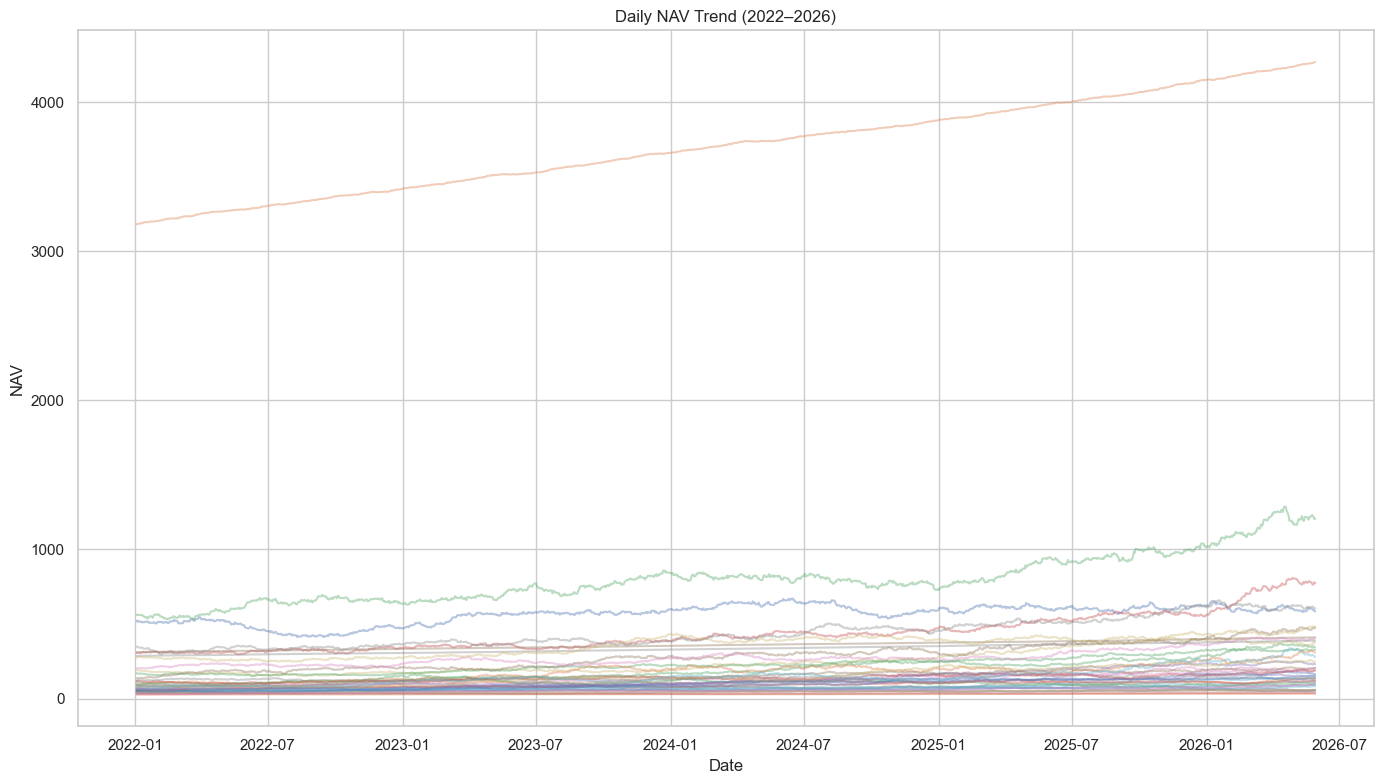

In [12]:
plt.figure(figsize=(14,8))

for code in nav["amfi_code"].unique():

    scheme = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        scheme["date"],
        scheme["nav"],
        alpha=0.4
    )

plt.title("Daily NAV Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.tight_layout()

# SAVE FIRST
plt.savefig(
    chart_path / "nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved successfully")

# SHOW AFTER SAVE
plt.show()

### Insight

- Most schemes show a steady upward NAV trend between 2022–2026.
- Several funds significantly outperformed peers.
- Market corrections are visible during selected periods but long-term growth remains positive.

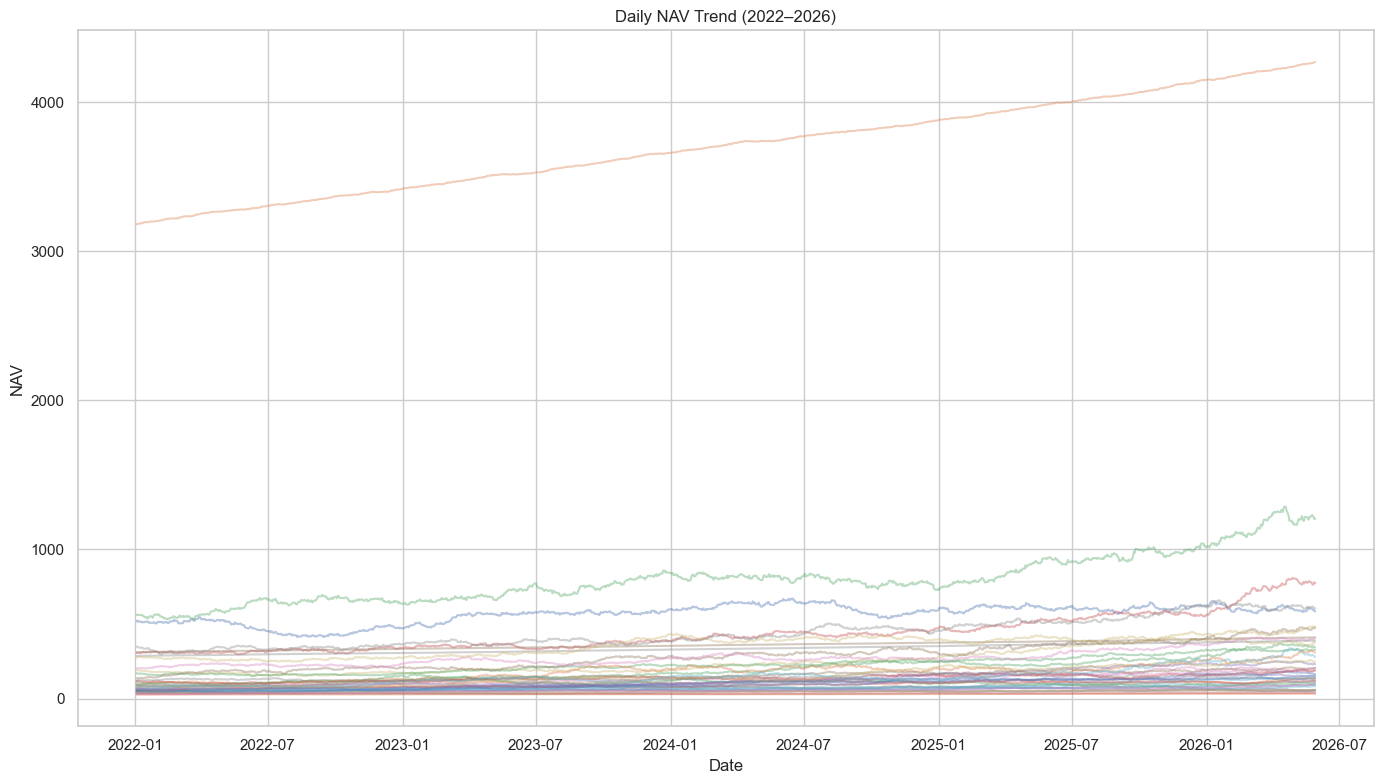

In [14]:
fig, ax = plt.subplots(figsize=(14,8))

for code in nav["amfi_code"].unique():

    scheme = nav[
        nav["amfi_code"] == code
    ]

    ax.plot(
        scheme["date"],
        scheme["nav"],
        alpha=0.4
    )

ax.set_title("Daily NAV Trend (2022–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("NAV")

fig.tight_layout()

fig.savefig(
    chart_path / "nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
print(nav.head())

print("\nShape:")
print(nav.shape)

print("\nColumns:")
print(nav.columns)

print("\nDate datatype:")
print(nav["date"].dtype)

        date  amfi_code       nav
0 2022-01-03     100016  520.4608
1 2022-01-04     100016  515.0971
2 2022-01-05     100016  521.7239
3 2022-01-06     100016  515.7880
4 2022-01-07     100016  515.1639

Shape:
(64320, 3)

Columns:
Index(['date', 'amfi_code', 'nav'], dtype='str')

Date datatype:
datetime64[us]


## AUM Growth by Fund House

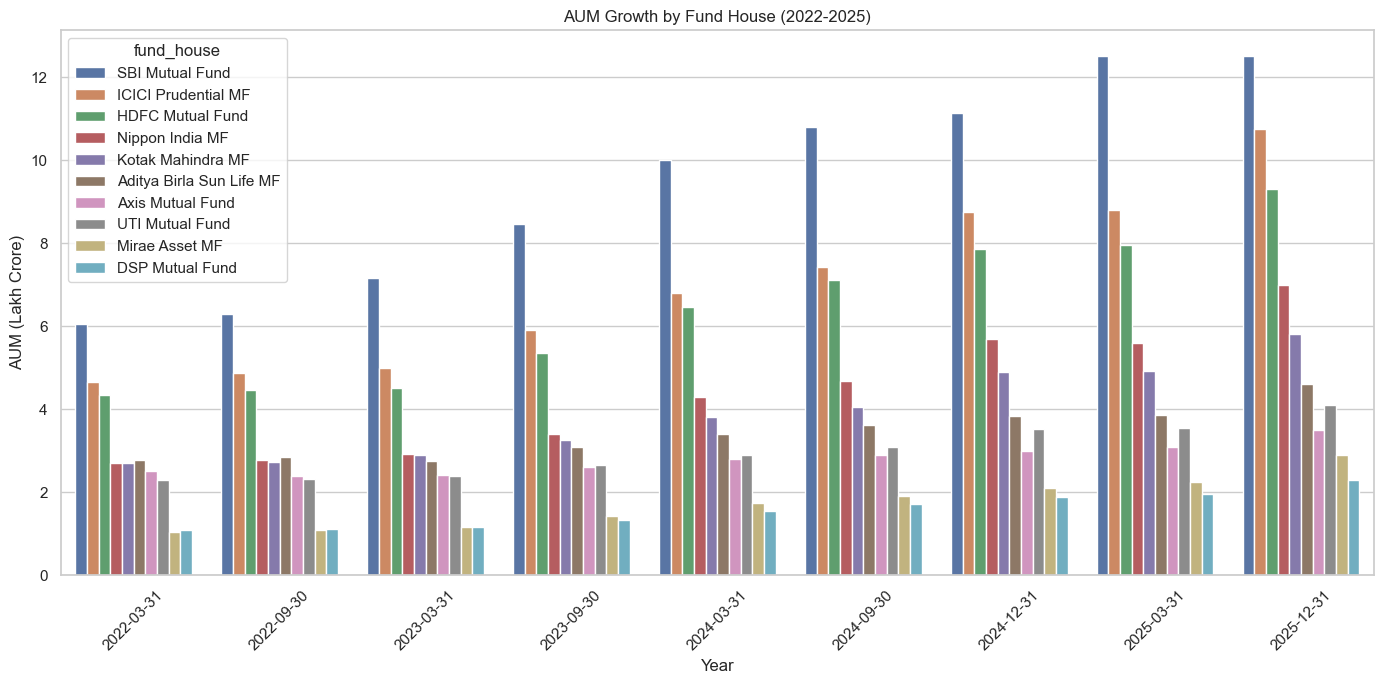

In [15]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    chart_path / "aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- SBI Mutual Fund consistently maintains the highest AUM.
- Major AMCs show steady year-on-year growth.
- Industry AUM expanded significantly from 2022 to 2025.

## SIP Inflow Trend

In [16]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

## Category-wise Inflow Heatmap

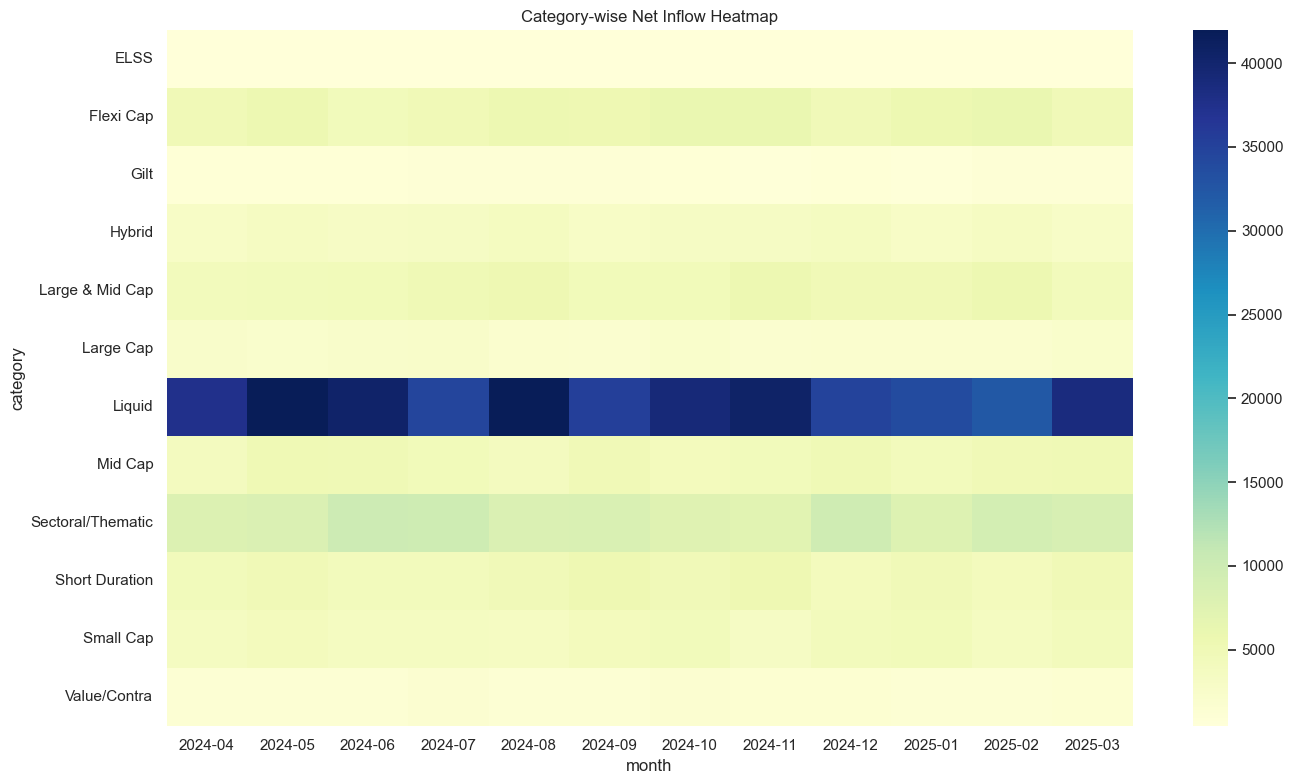

In [17]:
category_pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    chart_path / "category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Flexi Cap and Mid Cap categories receive strong inflows.
- Some categories show cyclical investor preference.
- Equity-oriented funds dominate net inflows.

## Investor Age Distribution

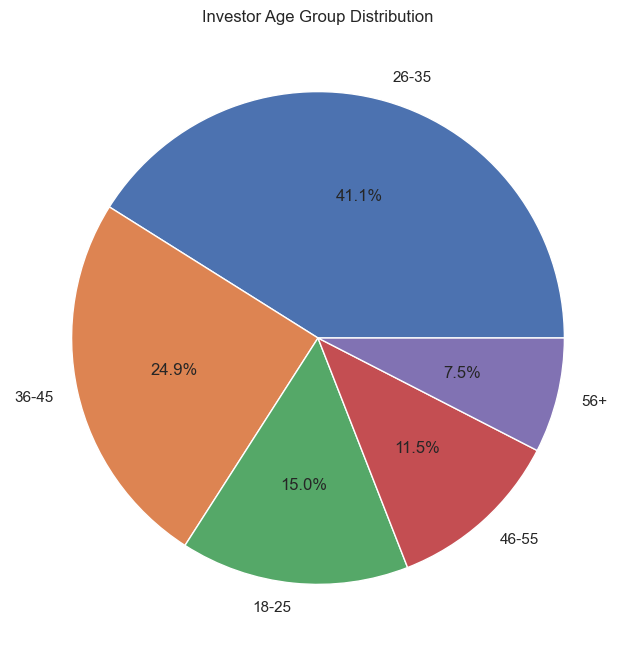

In [18]:
age_counts = (
    transactions["age_group"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    chart_path / "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Most investors belong to the working-age population.
- Younger investors contribute significantly through SIPs.

## SIP Amount by Age Group

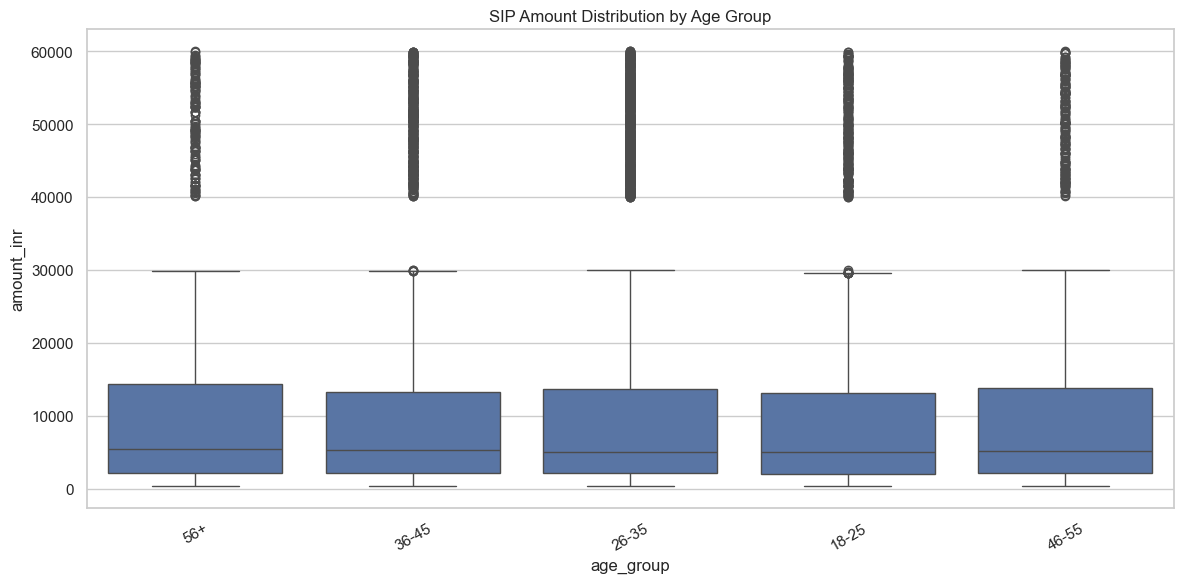

In [19]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    chart_path / "sip_boxplot_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Higher age groups generally invest larger SIP amounts.
- Outliers indicate high-net-worth investors.

## Investment by State

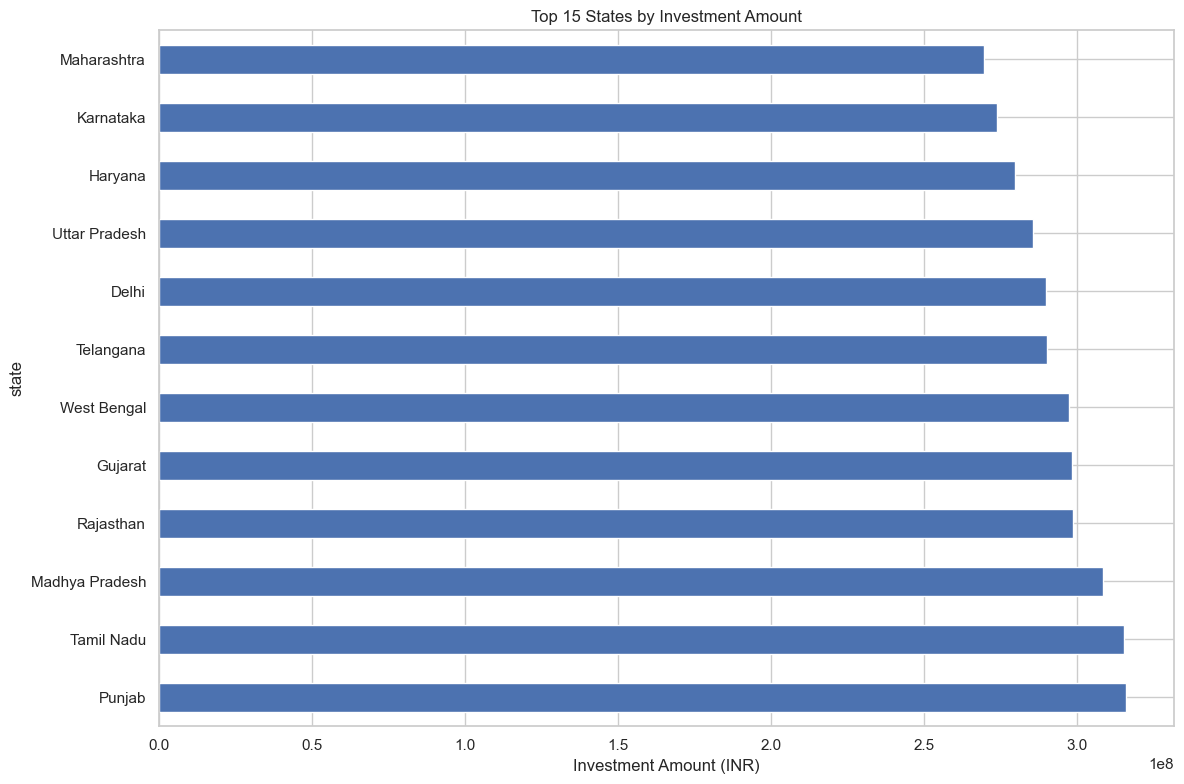

In [20]:
state_investment = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_investment.head(15).plot(
    kind="barh"
)

plt.title("Top 15 States by Investment Amount")

plt.xlabel("Investment Amount (INR)")

plt.tight_layout()

plt.savefig(
    chart_path / "state_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Metropolitan states contribute the largest share of investments.
- Investment participation is concentrated in a few major regions.

## T30 vs B30 Investor Distribution

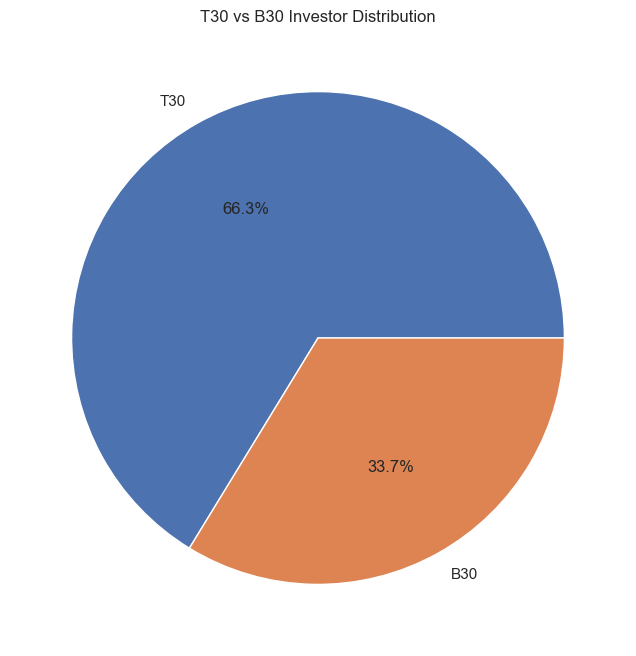

In [21]:
tier_counts = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    chart_path / "t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- T30 cities contribute a significant portion of investments.
- B30 participation indicates growing mutual fund penetration.

## Industry Folio Growth

In [22]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Growth"
)

fig.show()

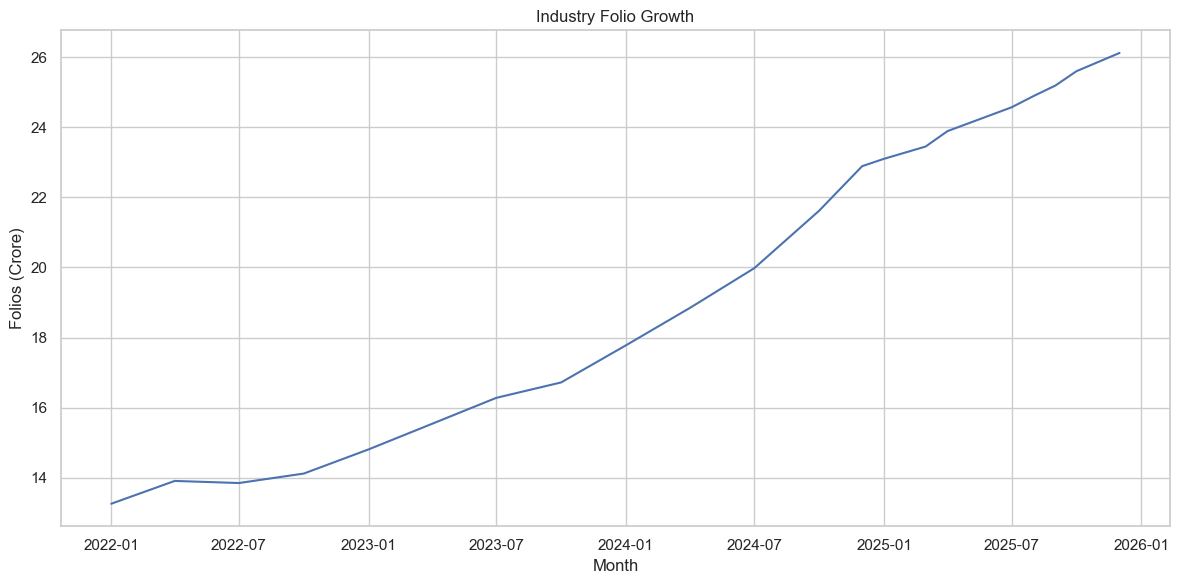

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.tight_layout()

plt.savefig(
    chart_path / "folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Fund Correlation Matrix

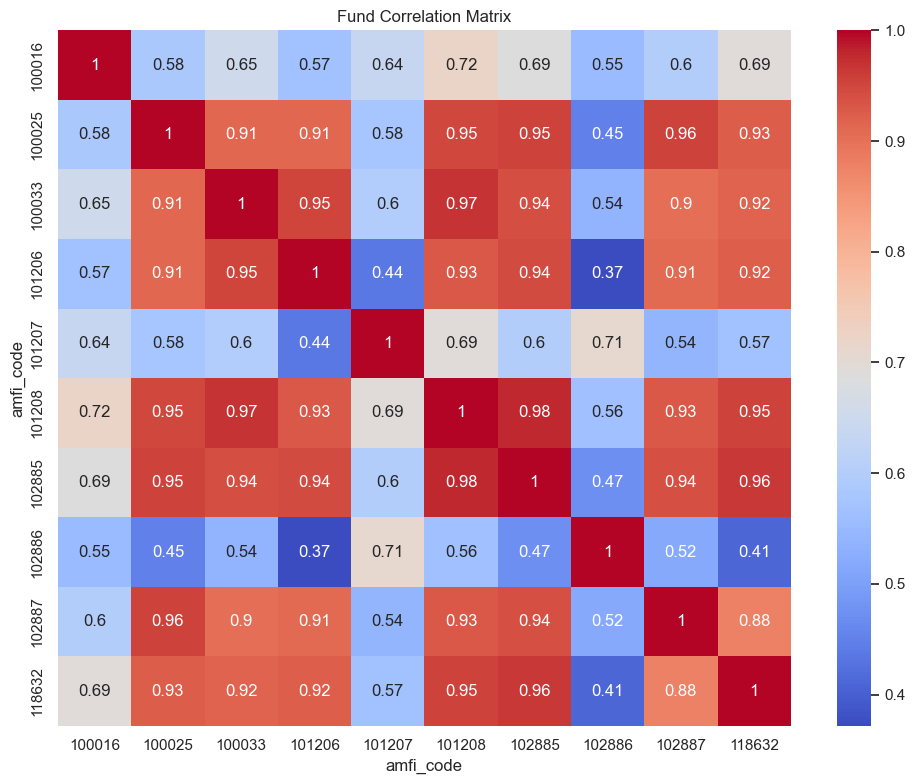

In [24]:
selected_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

corr_data = nav[
    nav["amfi_code"].isin(selected_funds)
]

corr_matrix = (
    corr_data
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
    .corr()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fund Correlation Matrix")

plt.tight_layout()

plt.savefig(
    chart_path / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Most large-cap funds show strong positive correlation.
- Diversification opportunities exist across categories.

## Sector Allocation

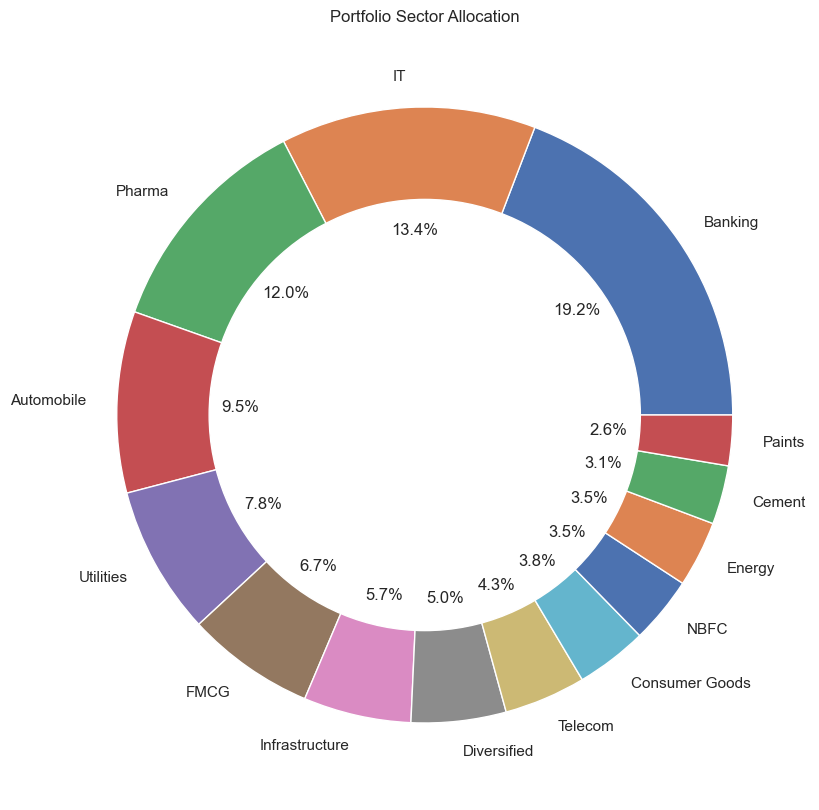

In [25]:
sector_weights = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title("Portfolio Sector Allocation")

plt.savefig(
    chart_path / "sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Financials and Technology dominate equity portfolios.
- Sector diversification varies significantly across schemes.

## Top 10 Funds by AUM

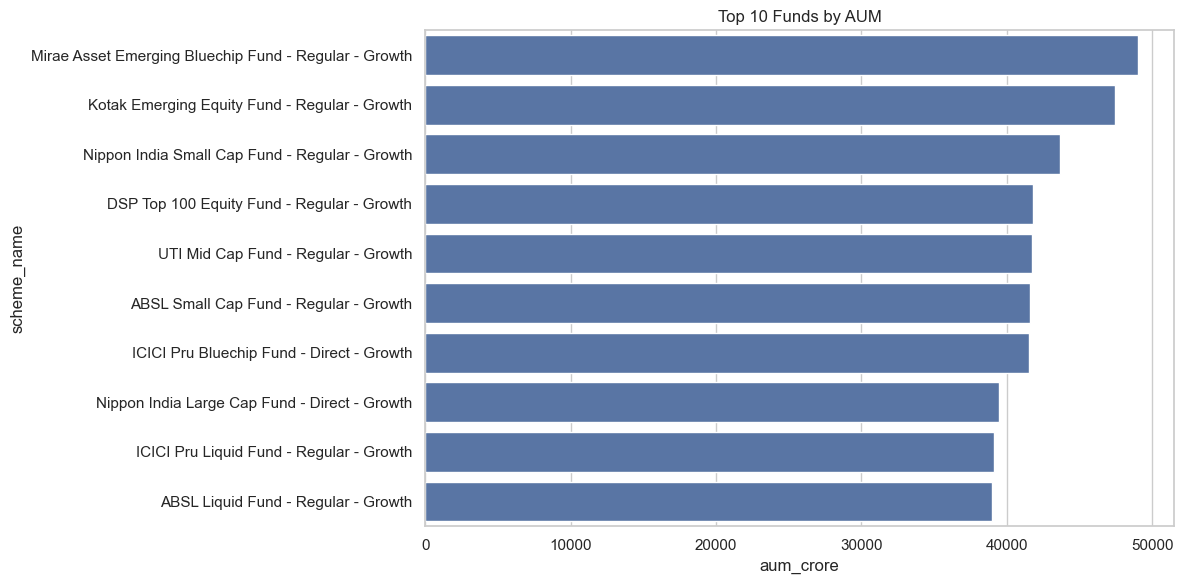

In [26]:
top_aum = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.tight_layout()

plt.savefig(
    chart_path / "top10_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Expense Ratio Distribution

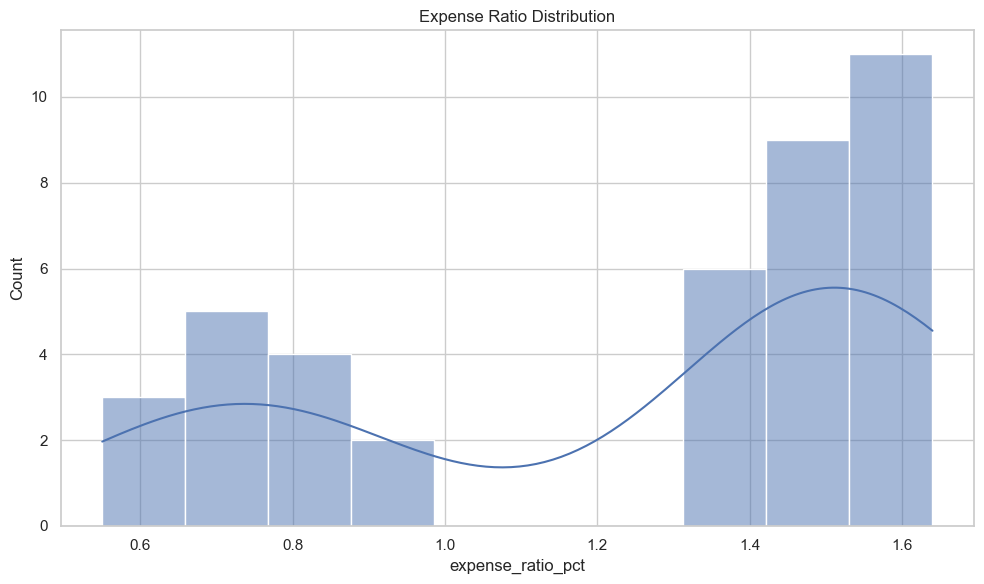

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.tight_layout()

plt.savefig(
    chart_path / "expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Risk Grade Distribution

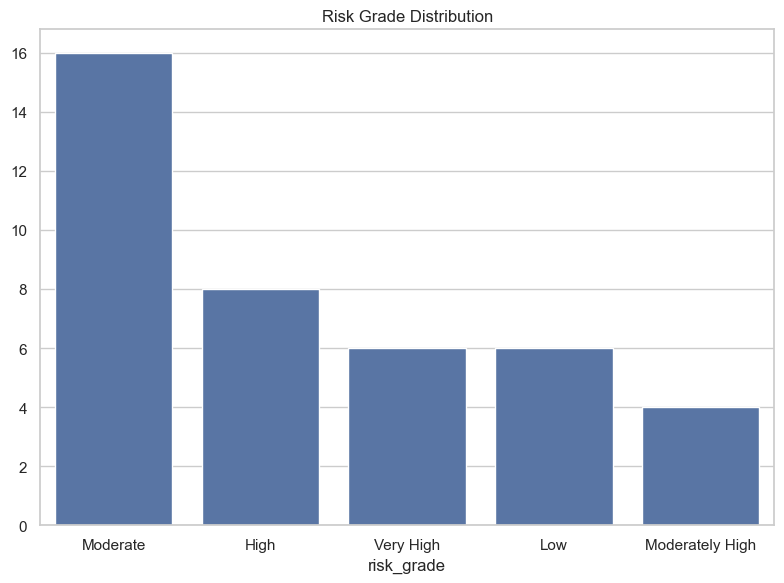

In [28]:
risk_counts = (
    performance["risk_grade"]
    .value_counts()
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Risk Grade Distribution")

plt.tight_layout()

plt.savefig(
    chart_path / "risk_grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Number of Schemes by Fund House

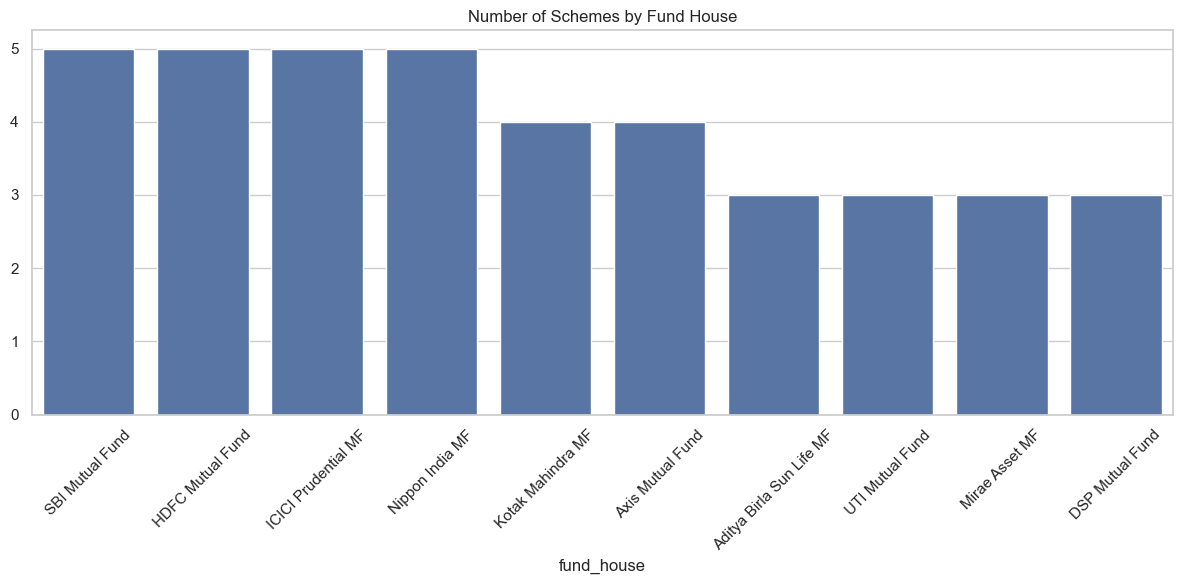

In [29]:
scheme_counts = (
    fund_master["fund_house"]
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=scheme_counts.index,
    y=scheme_counts.values
)

plt.xticks(rotation=45)

plt.title("Number of Schemes by Fund House")

plt.tight_layout()

plt.savefig(
    chart_path / "scheme_count_by_amc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Transaction Type Distribution

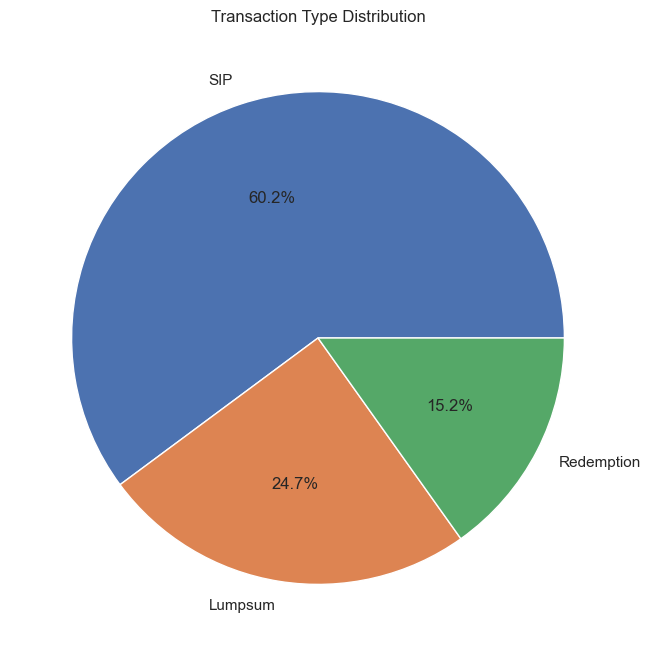

In [30]:
txn_counts = (
    transactions["transaction_type"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    txn_counts,
    labels=txn_counts.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.savefig(
    chart_path / "transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Key EDA Findings

1. Mutual fund NAVs displayed a strong long-term upward trend between 2022 and 2026.

2. SBI Mutual Fund maintained the highest Assets Under Management among major AMCs.

3. SIP inflows increased consistently over the study period, indicating growing retail participation.

4. Flexi Cap, Mid Cap, and Large & Mid Cap categories attracted significant investor inflows.

5. The majority of investors belong to working-age groups, highlighting strong retail participation.

6. Metropolitan states contribute the largest share of investment activity.

7. B30 participation continues to grow, indicating deeper mutual fund penetration beyond major cities.

8. Industry folio counts increased substantially, reflecting expanding investor adoption.

9. Most mutual fund schemes exhibit strong positive correlations, especially within similar categories.

10. Financial, Banking, and Technology sectors account for a significant portion of portfolio allocations.